# Chapter 13. 양자 합성곱 신경망(Quantum Convolutional Neural Network, QCNN)

## 1. 소개

이 튜토리얼에서는 Cong et al. [1]에 의해 처음 제안된 양자 합성곱 신경망(QCNN)에 대해 논의한다. Qiskit에서 합성곱 층과 풀링 층 모두를 양자 회로를 사용하여 모델링함으로써 QCNN을 구현한다. 이러한 네트워크를 구축한 후, 픽셀화된 이미지에서 수평 선과 수직 선을 구분하도록 훈련한다. 다음 튜토리얼은 따라서 다음과 같이 나뉜다;

1. QCNN과 CCNN 간의 차이점
2. QCNN의 구성 요소
3. 데이터 생성
4. QCNN 구축
5. QCNN 훈련
6. QCNN 테스트
7. 참고 자료

우리는 먼저 이 튜토리얼에 필요한 라이브러리와 패키지를 가져온다.

In [2]:
# 필요한 라이브러리 및 패키지 임포트
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import z_feature_map
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN
from sklearn.model_selection import train_test_split

algorithm_globals.random_seed = 12345
estimator = Estimator()

## 1. QCNN과 CCNN의 차이점

### 1.1 고전적 합성곱 신경망(Classical Convolutional Neural Networks)

고전적 합성곱 신경망(CCNN)은 주어진 입력의 특정 특징과 패턴을 결정할 수 있는 인공 신경망의 부분 집합이다. 이러한 이유로 이들은 일반적으로 이미지 인식 및 오디오 처리에 사용된다.

특징을 결정하는 능력은 CCNN에서 사용되는 두 가지 유형의 층, 즉 합성곱 층과 풀링 층의 결과이다.

CCNN의 예는 Figure 1에서 볼 수 있으며, CCNN은 입력 이미지가 고양이 또는 개를 포함하는지를 결정하도록 훈련된다. 이를 위해 입력 이미지는 일련의 교대 합성곱(C) 및 풀링 층(P)을 통과하며, 이들은 모두 패턴을 감지하고 각 패턴을 고양이 또는 개와 연결한다. 완전히 연결된 층(FC)은 입력 이미지가 고양이 또는 개였는지를 결정할 수 있는 출력을 제공한다.

합성곱 층은 커널을 사용하며, 커널은 특정 입력의 특징과 패턴을 결정할 수 있다. 이의 한 예는 이미지의 특징 감지이며, 서로 다른 층은 입력 이미지의 특정 패턴을 감지한다. 이는 Figure 1에서 시연되며, $l^{th}$ 층은 $ij$ 평면을 따라 특징과 패턴을 인식한다. 그러면 이러한 특징을 훈련 과정에서 주어진 출력과 연결할 수 있으며, 이 과정을 사용하여 데이터셋을 훈련할 수 있다.

반면에, 풀링 층은 입력 데이터의 차원성을 감소시켜 CCNN의 계산 비용과 학습 파라미터 수를 감소시킨다. CCNN의 개략도는 아래에서 볼 수 있다.

CCNN에 대한 자세한 정보는 [2]를 참조하십시오.

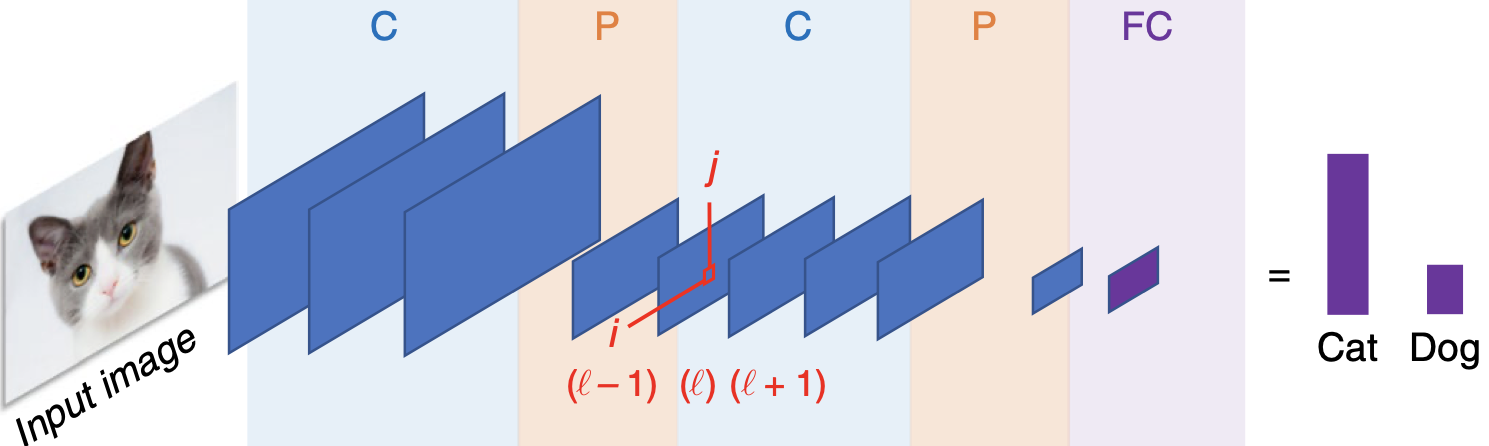
Figure 1. 고양이와 개 이미지를 분류하기 위해 CCNN을 사용하는 방법의 개략도. 여기서 우리는 풀링 층의 사용으로 인한 차원성이 감소하는 여러 합성곱 및 풀링 층이 적용되는 것을 본다. CCNN의 출력은 입력 이미지가 고양이인지 개인지를 결정한다. 이미지는 [1]에서 얻었다.

### 1.2 양자 합성곱 신경망(Quantum Convolutional Neural Networks)

양자 합성곱 신경망(QCNN)은 CCNN과 유사한 방식으로 동작한다. 먼저 Qiskit의 ZFeatureMap 또는 ZZFeatureMap이나 회로 라이브러리에서 사용 가능한 다른 특징 맵을 사용하여 픽셀화된 이미지를 양자 회로로 인코딩한다.

이미지를 인코딩한 후, 다음 섹션에서 정의하는 교대 합성곱 및 풀링 층을 적용한다. 이러한 교대 층을 적용함으로써 우리의 회로의 차원성을 감소시켜 한 개의 큐비트가 남을 때까지 진행한다. 그러면 이 하나의 남은 큐비트의 출력을 측정하여 입력 이미지를 분류할 수 있다.

양자 합성곱 층은 우리의 회로에서 큐비트 간의 관계를 인식하고 결정하는 일련의 두 큐비트 단위 연산자로 구성된다. 이 단위 게이트는 다음 섹션에서 아래에 정의된다.

양자 풀링 층의 경우, 차원을 감소시키기 위해 고전적으로 수행하는 것과 동일하게 할 수 없다. 즉, 회로에서 큐비트 수를 감소시킬 수 없다. 대신, 우리는 각 큐비트에 대해 특정 지점까지 연산을 수행한 다음 특정 층에서 특정 큐비트를 무시함으로써 큐비트 수를 감소시킨다. 우리가 특정 큐비트에 대해 연산을 중지하는 이러한 층을 '풀링 층'이라고 부른다. 풀링 층의 자세한 내용은 다음 섹션에서 더 논의된다.

QCNN에서, 각 층은 매개변수화된 회로를 포함하며, 이는 각 층의 매개변수를 조정하여 출력 결과를 변경한다. QCNN을 훈련할 때, 이러한 매개변수들은 QCNN의 손실 함수를 감소시키기 위해 조정된다.

간단한 4개 큐비트 QCNN의 예는 아래에서 볼 수 있다.

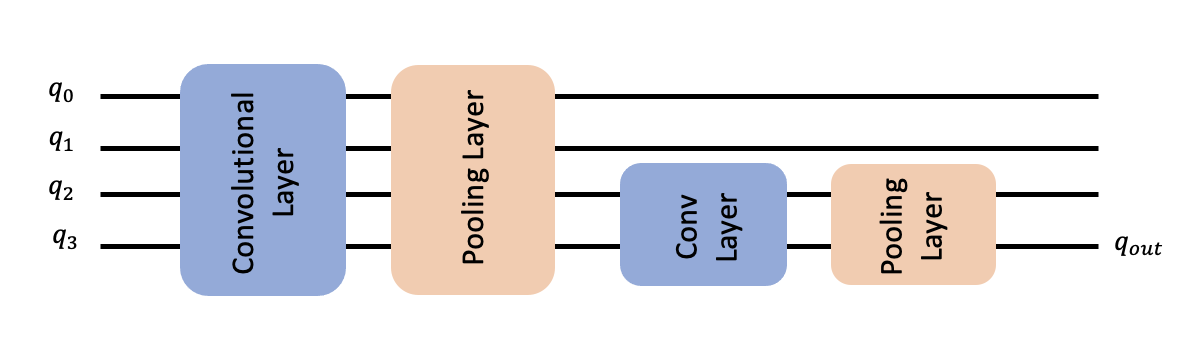

*그림 2: 4큐비트 양자 합성곱 신경망(QCNN) 예시*


Figure 2: 4개의 큐비트를 포함하는 QCNN의 예. 첫 번째 합성곱 층은 모든 큐비트에 작용한다. 이어서 첫 번째 풀링 층이 따르며, 이는 QCNN의 차원성을 4개 큐비트에서 2개 큐비트로 감소시킨다(처음 두 개를 무시함). 두 번째 합성곱 층은 QCNN에서 여전히 사용 중인 두 큐비트 사이의 특징을 감지하며, 그 다음 또 다른 풀링 층이 따르며, 이는 차원성을 2개 큐비트에서 1개로 감소시키며, 이것이 우리의 출력 큐비트가 된다.

## 2. QCNN의 구성 요소

이 튜토리얼의 섹션 1에서 논의한 바와 같이, CCNN은 합성곱 층과 풀링 층을 모두 포함할 것이다. 여기서 우리는 양자 회로에 적용된 게이트 측면에서 QCNN의 이러한 층을 정의하고 4개 큐비트에 대한 각 층의 예를 시연한다.

이러한 각 층은 훈련 과정 전체에서 손실 함수를 최소화하고 QCNN이 수평 선과 수직 선을 분류하도록 훈련하기 위해 조정되는 매개변수를 포함할 것이다.

이론적으로, 우리의 네트워크의 합성곱 및 풀링 층 모두에 대해 임의의 매개변수화된 회로를 적용할 수 있다. 예를 들어 [2]에서, Gellmann 행렬(3차원 Pauli 행렬의 일반화)은 큐비트의 쌍에 작용하는 각 단위 게이트에 대한 생성원으로 사용된다.

여기서 우리는 다른 접근 방식을 취하고 [3]에서 제안된 2-큐비트 단위를 기반으로 우리의 매개변수화된 회로를 형성한다. 이는 $U(4)$의 모든 단위 행렬이 다음과 같이 분해될 수 있음을 나타낸다

$$U = (A_1 \otimes A_2) \cdot N(\alpha, \beta, \gamma) \cdot (A_3 \otimes A_4)$$

여기서 $A_j \in \text{SU}(2)$, $\otimes$는 텐서 곱이고, $N(\alpha, \beta, \gamma) = exp(i[\alpha \sigma_x\sigma_x + \beta \sigma_y\sigma_y + \gamma \sigma_z\sigma_z ])$이며, $\alpha, \beta, \gamma$는 우리가 조정할 수 있는 매개변수이다.

이로부터, 각 단위는 15개의 매개변수에 따라 달라지며 QCNN이 전체 Hilbert 공간을 span 할 수 있으려면 QCNN의 각 단위는 15개의 매개변수를 각각 포함해야 함을 암시한다.

이 많은 양의 매개변수를 조정하는 것은 어려울 것이며 긴 훈련 시간으로 이어질 것이다. 이 문제를 극복하기 위해, 우리는 우리의 ansatz를 Hilbert 공간의 특정 부분공간으로 제한하고 2-큐비트 단위 게이트를 $N(\alpha, \beta, \gamma)$로 정의한다. 이러한 2-큐비트 단위는 [3]에서 보이는 바와 같이 아래에서 볼 수 있으며 QCNN의 각 층에서 모든 인접한 큐비트에 적용된다.

우리가 매개변수화된 층에 대한 2-큐비트 단위로 $N(\alpha, \beta, \gamma)$만 사용함으로써, 우리는 QCNN을 특정 부분공간으로 제한하고 있으며, 이 부분공간에는 최적 해가 포함되지 않을 수 있으며 QCNN의 정확도를 감소시킨다. 이 튜토리얼의 목적을 위해, 우리는 QCNN의 훈련 시간을 감소시키기 위해 이 매개변수화된 회로를 사용할 것이다.

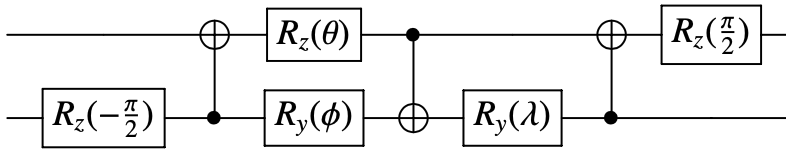

*그림 3: 매개변수화된 2큐비트 유니터리 회로(Parameterized Two-Qubit Unitary Circuit)*

Figure 3:
[3]에서 본 바와 같이, $N(\alpha, \beta, \gamma) = exp(i[\alpha \sigma_x\sigma_x + \beta \sigma_y\sigma_y + \gamma \sigma_z\sigma_z ])$에 대한 매개변수화된 2-큐비트 단위 회로이며, 여기서 $\alpha = \frac{\pi}{2} - 2\theta$, $\beta = 2\phi - \frac{\pi}{2}$ 그리고 $\gamma = \frac{\pi}{2} - 2\lambda$는 회로에서 보이는 바와 같다. 이 2-큐비트 단위는 우리의 특징 맵에서 모든 인접한 큐비트에 적용될 것이다.

### 2.1 합성곱 층(Convolutional Layer)

이 튜토리얼의 다음 단계는 우리 QCNN의 합성곱 층을 정의하는 것이다. 이러한 층은 특징 맵을 사용하여 데이터가 인코딩된 후 큐비트에 적용된다.

이를 위해 우리는 먼저 우리의 합성곱 및 풀링 층을 생성하는 데 사용될 매개변수화된 단위 게이트를 결정해야 한다.

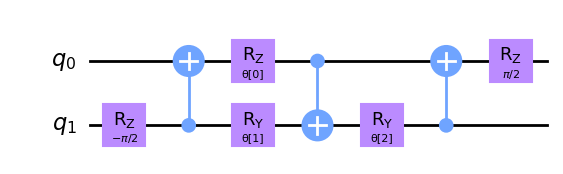

In [3]:
# [3]에서 정의된 2-큐비트 단위를 정의한다
# We now define a two qubit unitary as defined in [3]
def conv_circuit(params):
    target = QuantumCircuit(2)
    target.rz(-np.pi / 2, 1)
    target.cx(1, 0)
    target.rz(params[0], 0)
    target.ry(params[1], 1)
    target.cx(0, 1)
    target.ry(params[2], 1)
    target.cx(1, 0)
    target.rz(np.pi / 2, 0)
    return target


# Let's draw this circuit and see what it looks like
params = ParameterVector("θ", length=3)
circuit = conv_circuit(params)
circuit.draw("mpl", style="clifford")

이제 이러한 단위를 정의했으므로, 우리의 QCNN에서 합성곱 층에 대한 함수를 생성할 시간이다. 이를 위해, 아래의 ``conv_layer`` 함수에서 보이는 바와 같이 인접한 큐비트에 2-큐비트 단위를 적용한다.

먼저 모든 짝수 쌍의 큐비트에 2-큐비트 단위를 적용한 다음, 순환 결합 방식으로 홀수 쌍의 큐비트에 적용한다는 점에 유의한다. 즉, 인접한 큐비트가 결합되는 것처럼, 첫 번째 및 최종 큐비트도 단위 게이트를 통해 결합된다.

우리는 플롯할 때 편의상 우리의 양자 회로에 배리어를 추가하지만, 실제 QCNN에는 필요하지 않으며 다음 회로에서 추출할 수 있다.

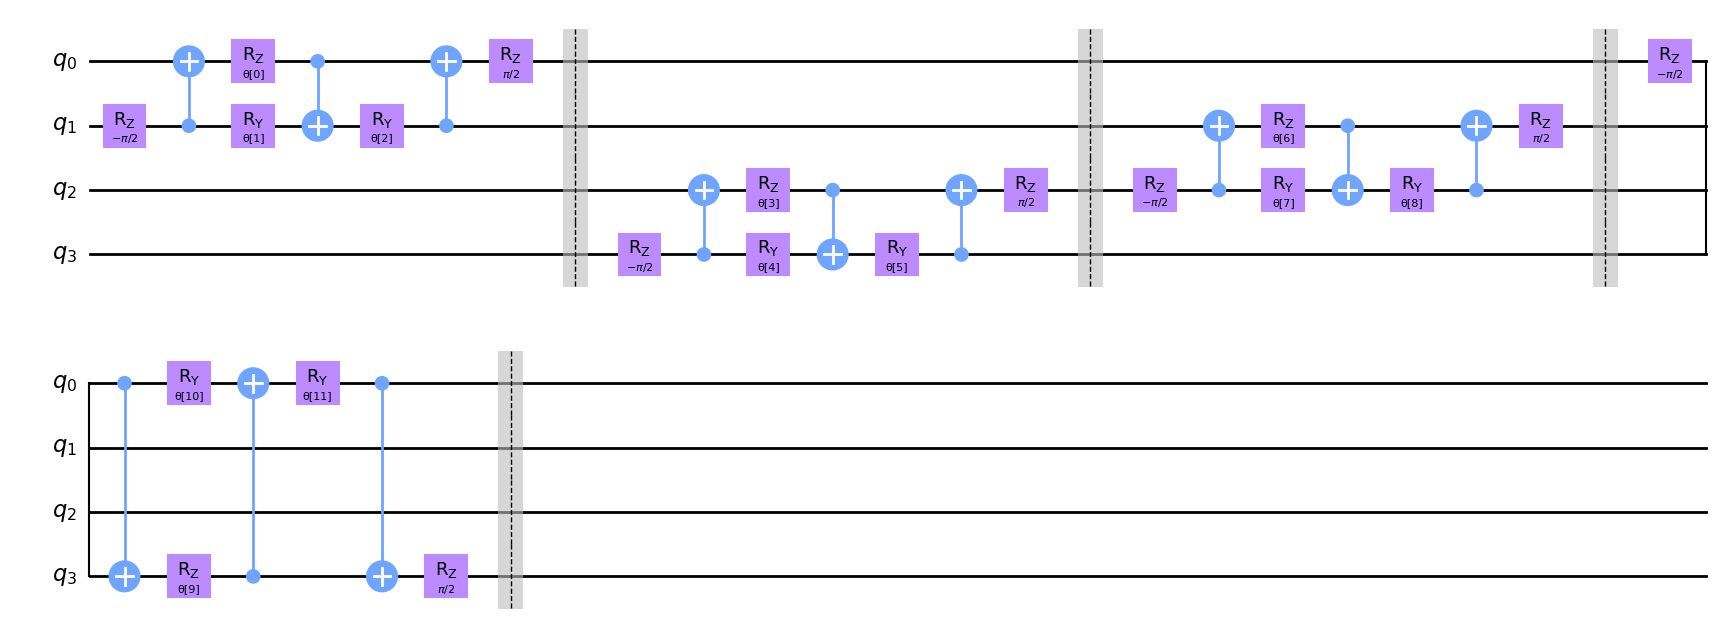

In [4]:
# 매개변수화된 합성곱 층을 생성한다
def conv_layer(num_qubits, param_prefix):
    qc = QuantumCircuit(num_qubits, name="Convolutional Layer")
    qubits = list(range(num_qubits))
    param_index = 0
    params = ParameterVector(param_prefix, length=num_qubits * 3)
    for q1, q2 in zip(qubits[0::2], qubits[1::2]):
        qc = qc.compose(conv_circuit(params[param_index : (param_index + 3)]), [q1, q2])
        qc.barrier()
        param_index += 3
    for q1, q2 in zip(qubits[1::2], qubits[2::2] + [0]):
        qc = qc.compose(conv_circuit(params[param_index : (param_index + 3)]), [q1, q2])
        qc.barrier()
        param_index += 3

    qc_inst = qc.to_instruction()

    qc = QuantumCircuit(num_qubits)
    qc.append(qc_inst, qubits)
    return qc


circuit = conv_layer(4, "θ")
circuit.decompose().draw("mpl", style="clifford")

### 2.2 풀링 층(Pooling Layer)

풀링 층의 목적은 우리의 양자 회로의 차원을 감소시키는 것이다. 즉, 우리의 회로에서 큐비트 수를 감소시키면서 이전에 학습된 데이터로부터 가능한 한 많은 정보를 유지하는 것이다. 큐비트의 양을 감소시키는 것은 또한 QCNN이 학습해야 할 매개변수의 수가 감소하므로 전체 회로의 계산 비용을 감소시킨다.

그러나 우리의 양자 회로에서 큐비트의 양을 단순히 감소시킬 수는 없다. 이러한 이유로, 우리는 고전적인 접근 방식과 비교하여 다른 방식으로 풀링 층을 정의해야 한다.

우리의 회로에서 큐비트 수를 '인위적으로' 감소시키기 위해, 우리는 먼저 우리의 시스템에서 $N$ 큐비트의 쌍을 생성하기 시작한다.

처음에 모든 큐비트를 페어링한 후, 우리는 이전에 설명한 우리의 일반화된 2-큐비트 단위를 각 쌍에 적용한다. 이 2-큐비트 단위를 적용한 후, 우리는 각 큐비트 쌍에서 하나의 큐비트를 무시하고 신경망의 나머지 부분에서는 무시한다.

이 층은 따라서 '결합'하는 전체 효과를 가지고 있다. 두 큐비트의 정보를 하나의 큐비트로 통합하는데, 이는 먼저 단위 회로를 적용하고, 한 큐비트의 정보를 다른 큐비트로 인코딩한 후, 회로의 나머지 부분에서 큐비트 중 하나를 무시하고 이에 대한 연산이나 측정을 수행하지 않는다.

우리는 또한 동적 회로를 적용하여 풀링 층에서 차원성을 감소시킬 수 있다는 점에 유의한다. 이는 회로의 특정 큐비트에 대한 측정을 수행하고 우리의 풀링 층에 중간 고전적 피드백 루프를 포함하는 것을 포함한다. 이러한 측정을 적용함으로써, 하나는 또한 회로의 차원성을 감소시킬 것이다.

이 튜토리얼에서 우리는 전자 접근 방식을 적용하고 각 풀링 층에서 큐비트를 무시한다. 이 접근 방식을 사용하여, 우리는 따라서 $N$ 큐비트 양자 회로의 차원을 $N/2$로 변환하는 QCNN 풀링 층을 생성한다.

이를 위해, 우리는 먼저 2-큐비트 시스템을 1개로 변환하는 2-큐비트 단위를 정의한다.

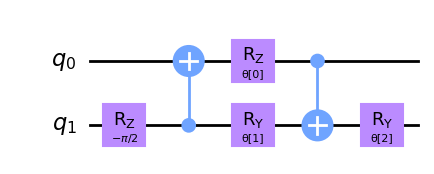

In [5]:
# 풀링 회로를 정의한다
def pool_circuit(params):
    target = QuantumCircuit(2)
    target.rz(-np.pi / 2, 1)
    target.cx(1, 0)
    target.rz(params[0], 0)
    target.ry(params[1], 1)
    target.cx(0, 1)
    target.ry(params[2], 1)

    return target


params = ParameterVector("θ", length=3)
circuit = pool_circuit(params)
circuit.draw("mpl", style="clifford")

이 2-큐비트 단위 회로를 적용한 후, 우리는 향후 층에서 첫 번째 큐비트(q0)를 무시하고 우리의 QCNN에서만 두 번째 큐비트(q1)를 사용한다

우리는 이 2-큐비트 풀링 층을 다양한 큐비트 쌍에 적용하여 N 큐비트에 대한 우리의 풀링 층을 생성한다. 예를 들어, 우리는 그것을 4개 큐비트에 대해 플롯한다.

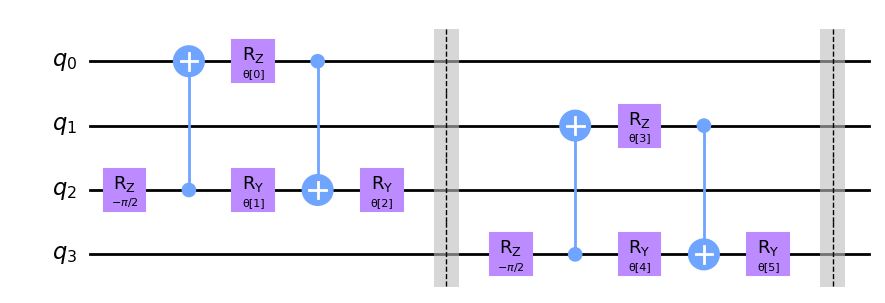

In [6]:
# 풀링 층을 정의한다
def pool_layer(sources, sinks, param_prefix):
    num_qubits = len(sources) + len(sinks)
    qc = QuantumCircuit(num_qubits, name="Pooling Layer")
    param_index = 0
    params = ParameterVector(param_prefix, length=num_qubits // 2 * 3)
    for source, sink in zip(sources, sinks):
        qc = qc.compose(pool_circuit(params[param_index : (param_index + 3)]), [source, sink])
        qc.barrier()
        param_index += 3

    qc_inst = qc.to_instruction()

    qc = QuantumCircuit(num_qubits)
    qc.append(qc_inst, range(num_qubits))
    return qc


sources = [0, 1]
sinks = [2, 3]
circuit = pool_layer(sources, sinks, "θ")
circuit.decompose().draw("mpl", style="clifford")

이 특정 예에서, 우리는 4-큐비트 회로의 차원성을 마지막 두 큐비트로 감소시킨다. 즉, 이 특정 예에서 마지막 두 큐비트이다. 이 큐비트들은 다음 층에서 사용되는 반면, 처음 두 개는 QCNN의 나머지에 대해 무시된다.

## 3. 데이터 생성

CCNN의 일반적인 용도는 이미지 분류기이며, 여기서 CCNN은 합성곱 층의 특징 맵을 사용하여 픽셀화된 이미지의 특정 특징 및 패턴(예: 직선 또는 곡선)을 감지한다. 이러한 특징 간의 관계를 학습함으로써, 필기 숫자를 쉽게 분류하고 레이블을 지정할 수 있다.

고전적인 CNN의 특징과 패턴을 쉽게 인식할 수 있는 능력 때문에, 우리는 우리의 QCNN도 픽셀화된 이미지의 주어진 집합의 패턴 및 특징을 결정하도록 훈련할 것이며, 두 가지 다른 패턴을 분류할 것이다.

데이터셋을 단순화하기 위해, 우리는 2x4 픽셀화된 이미지만 고려한다. 우리의 QCNN이 구분하도록 훈련할 패턴은 이미지의 어느 곳에나 배치될 수 있으며 노이즈가 많은 배경과 함께 수평 또는 수직 선이 될 것이다.

우리는 먼저 이 데이터셋을 생성하기 시작한다. '수평' 또는 '수직' 선을 생성하기 위해, 우리는 픽셀 값이 $\frac{\pi}{2}$가 되도록 할당하며, 이는 우리의 픽셀화된 이미지에서 선을 나타낼 것이다. 우리는 모든 다른 픽셀에 $0$과 $\frac{\pi}{4}$ 사이의 무작위 값을 할당하여 노이즈가 많은 배경을 생성하여 노이즈가 많은 배경을 만든다.

데이터셋을 생성할 때, 우리는 각각 우리의 신경망을 훈련하고 테스트하는 데이터셋인 훈련 세트와 테스트 세트로 분할해야 한다는 점에 유의한다.

또한 QCNN이 두 패턴을 구분하기 위해 학습할 수 있도록 우리의 데이터셋에 레이블을 지정해야 한다. 이 예에서 우리는 수평 선이 있는 이미지에 -1로, 수직 선이 있는 이미지에 +1로 레이블을 지정한다.

In [7]:
# 데이터셋을 생성하는 함수
def generate_dataset(num_images):
    images = []
    labels = []
    hor_array = np.zeros((6, 8))
    ver_array = np.zeros((4, 8))

    j = 0
    for i in range(0, 7):
        if i != 3:
            hor_array[j][i] = np.pi / 2
            hor_array[j][i + 1] = np.pi / 2
            j += 1

    j = 0
    for i in range(0, 4):
        ver_array[j][i] = np.pi / 2
        ver_array[j][i + 4] = np.pi / 2
        j += 1

    for n in range(num_images):
        rng = algorithm_globals.random.integers(0, 2)
        if rng == 0:
            labels.append(-1)
            random_image = algorithm_globals.random.integers(0, 6)
            images.append(np.array(hor_array[random_image]))
        elif rng == 1:
            labels.append(1)
            random_image = algorithm_globals.random.integers(0, 4)
            images.append(np.array(ver_array[random_image]))

        # Create noise
        for i in range(8):
            if images[-1][i] == 0:
                images[-1][i] = algorithm_globals.random.uniform(0, np.pi / 4)
    return images, labels

이제 아래에서 우리의 데이터셋을 생성하고 테스트 및 훈련 데이터셋으로 분할해 보자. 우리는 분할이 이 노트북을 실행할 때마다 동일하도록 `random_state`를 전달하여 최종 결과가 변하지 않도록 한다.

In [8]:
# 데이터셋을 생성하고 훈련/테스트 세트로 분할한다
images, labels = generate_dataset(50)

train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.3, random_state=246
)

우리의 데이터셋에서 몇 가지 예를 보자

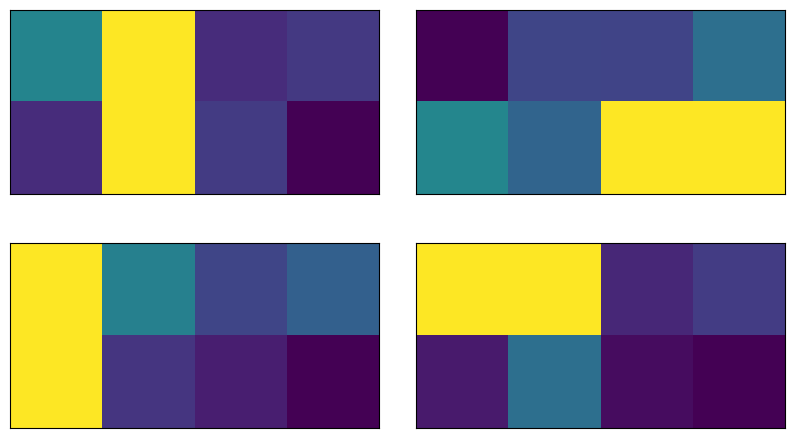

In [9]:
# 데이터셋의 시각화
fig, ax = plt.subplots(2, 2, figsize=(10, 6), subplot_kw={"xticks": [], "yticks": []})
for i in range(4):
    ax[i // 2, i % 2].imshow(
        train_images[i].reshape(2, 4),  # Change back to 2 by 4
        aspect="equal",
    )
plt.subplots_adjust(wspace=0.1, hspace=0.025)

우리가 볼 수 있듯이 각 이미지는 QCNN이 구분하는 방법을 배울 수직 또는 수평 선을 포함한다. 이제 우리의 데이터셋을 구축했으므로, QCNN의 구성 요소에 대해 논의하고 우리의 모델을 구축할 시간이다.

## 4. QCNN 모델링

이제 우리는 합성곱 층을 모두 정의했으므로 교대 풀링 및 합성곱 층으로 구성될 우리의 QCNN을 구축할 시간이다.

우리의 데이터셋의 이미지가 8개의 픽셀을 포함하므로, 우리는 우리의 QCNN에서 8개의 큐비트를 사용할 것이다.

우리는 특징 맵을 적용하여 우리의 데이터셋을 우리의 QCNN으로 인코딩한다. z_feature_map 또는 zz_feature_map과 같은 Qiskit의 기본 제공 특징 맵 중 하나를 사용하여 특징 맵을 생성할 수 있다.

이 데이터셋에 대한 여러 다양한 특징 맵을 분석한 후, QCNN이 Z 특징 맵을 사용할 때 최대 정확도를 얻는 것으로 나타났다. 따라서 튜토리얼의 나머지 부분에서 우리는 아래에서 볼 수 있는 Z 특징 맵을 사용할 것이다.

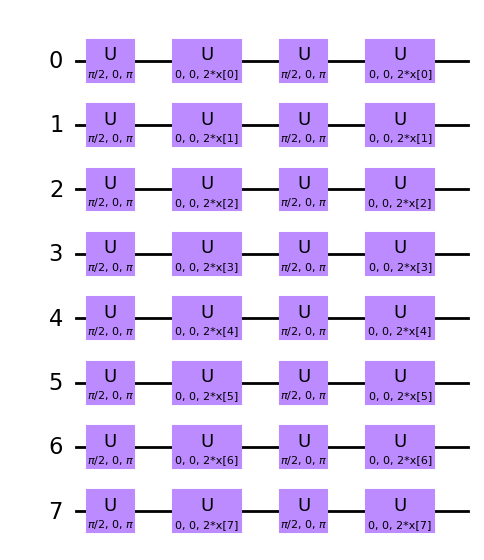

In [10]:
# 특징 맵을 생성하고 시각화한다
feature_map = z_feature_map(8)
feature_map.decompose().draw("mpl", style="clifford")

우리는 우리의 QCNN에 대한 함수를 생성하며, 이는 아래의 개략도에서 볼 수 있는 교대 합성곱 및 풀링 층의 3세트를 포함할 것이다. 풀링 층의 사용을 통해, 우리는 따라서 우리의 QCNN의 차원성을 8개 큐비트에서 1개로 감소시킨다.

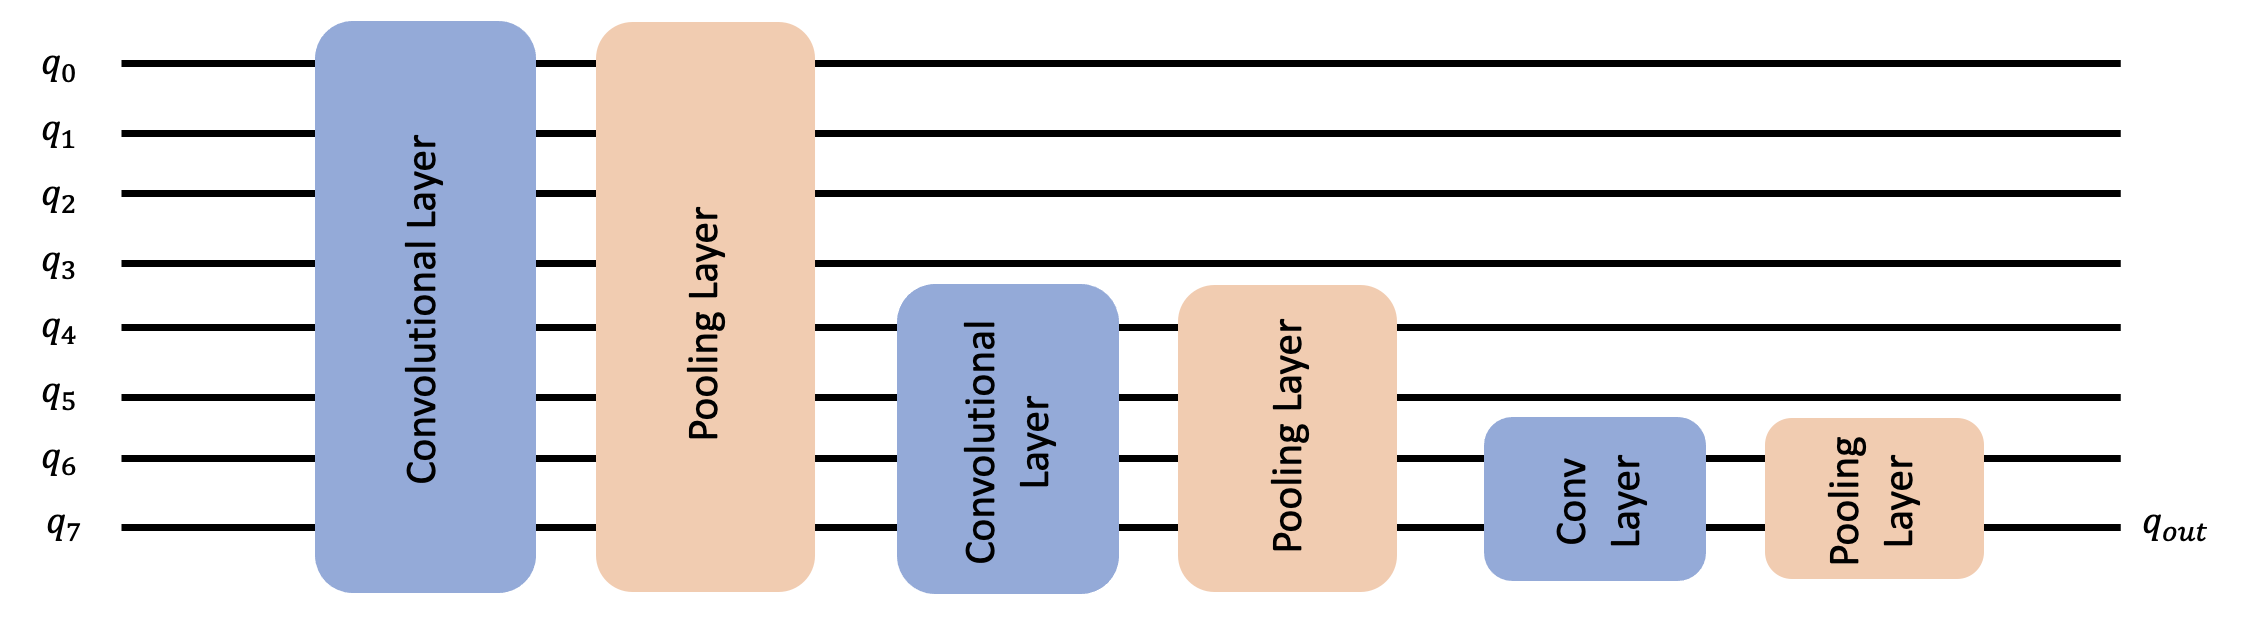

*그림: 양자 합성곱 신경망(QCNN) 전체 아키텍처*

수평 선과 수직 선의 우리의 이미지 데이터셋을 분류하기 위해, 우리는 최종 큐비트의 Pauli Z 연산자의 기댓값을 측정한다. 얻은 값이 +1 또는 -1에 따라, 우리는 입력 이미지가 수평 또는 수직 선을 포함했다고 결론을 내릴 수 있다.

## 5. QCNN 훈련

다음 단계는 우리의 훈련 데이터를 사용하여 우리의 모델을 구축하는 것이다.

우리의 시스템을 분류하기 위해, 우리는 출력 회로에서 측정을 수행한다. 우리가 얻을 값은 따라서 우리의 입력 데이터가 수직 선 또는 수평 선을 포함하는지를 분류할 것이다.

이 튜토리얼에서 선택한 측정은 $<Z>$이다. 즉, 최종 큐비트에 대한 Pauli Z 큐비트의 기댓값이다. 이 기댓값을 측정함으로써, 우리는 +1 또는 -1을 얻으며, 이는 각각 수직 또는 수평 선에 해당한다.

In [11]:
# 전체 QCNN 회로를 구축한다
feature_map = z_feature_map(8)

ansatz = QuantumCircuit(8, name="Ansatz")

# First Convolutional Layer
ansatz.compose(conv_layer(8, "c1"), list(range(8)), inplace=True)

# First Pooling Layer
ansatz.compose(pool_layer([0, 1, 2, 3], [4, 5, 6, 7], "p1"), list(range(8)), inplace=True)

# Second Convolutional Layer
ansatz.compose(conv_layer(4, "c2"), list(range(4, 8)), inplace=True)

# Second Pooling Layer
ansatz.compose(pool_layer([0, 1], [2, 3], "p2"), list(range(4, 8)), inplace=True)

# Third Convolutional Layer
ansatz.compose(conv_layer(2, "c3"), list(range(6, 8)), inplace=True)

# Third Pooling Layer
ansatz.compose(pool_layer([0], [1], "p3"), list(range(6, 8)), inplace=True)

# Combining the feature map and ansatz
circuit = QuantumCircuit(8)
circuit.compose(feature_map, range(8), inplace=True)
circuit.compose(ansatz, range(8), inplace=True)

observable = SparsePauliOp.from_list([("Z" + "I" * 7, 1)])

# we decompose the circuit for the QNN to avoid additional data copying
qnn = EstimatorQNN(
    circuit=circuit.decompose(),
    observables=observable,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


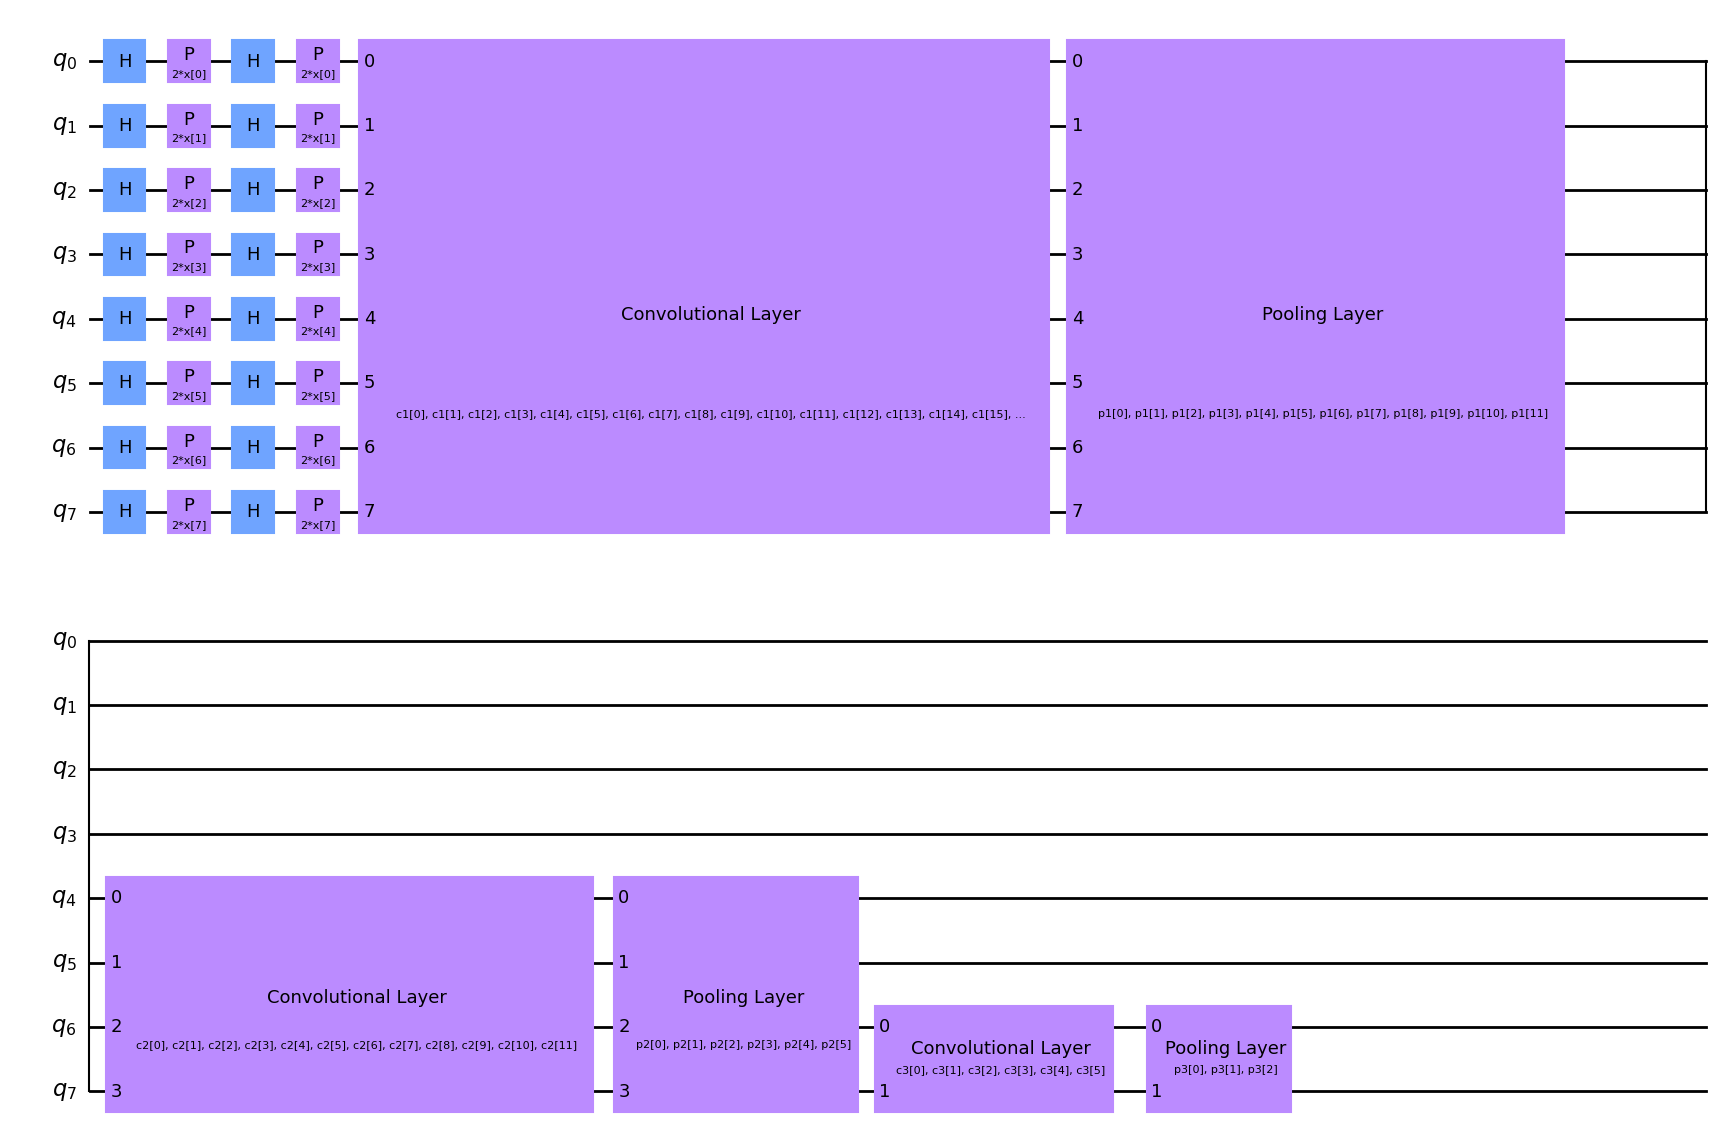

In [12]:
# 회로를 시각화한다
circuit.draw("mpl", style="clifford")

우리는 또한 우리의 모델을 훈련할 때 사용할 콜백 함수를 정의할 것이다. 이를 통해 우리는 우리의 훈련 과정에서 각 반복 당 손실 함수를 보고 그릴 수 있다.

In [13]:
# 콜백 함수를 정의한다
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

이 예에서, 우리는 COBYLA 최적화기를 사용하여 우리의 분류기를 훈련할 것이며, 이는 분류 기계 학습 알고리즘에 일반적으로 사용되는 수치 최적화 방법이다.

그러면 우리는 콜백 함수, 최적화기 및 위에서 생성한 우리의 QCNN의 연산자를 Qiskit Machine Learning의 기본 제공 신경망 분류기에 배치하며, 이를 사용하여 우리의 모델을 훈련할 수 있다.

모델 훈련은 오래 걸릴 수 있으므로 우리는 이미 모델을 몇 반복에 대해 미리 훈련하고 미리 훈련된 가중치를 저장했다. 우리는 `initial_point`를 미리 훈련된 가중치의 벡터로 설정하여 해당 지점부터 계속 훈련할 것이다.

In [15]:
# COBYLA 최적화기를 사용하여 신경망 분류기를 생성한다
with open("11_qcnn_initial_point.json", "r") as f:
    initial_point = json.load(f)

classifier = NeuralNetworkClassifier(
    qnn,
    optimizer=COBYLA(maxiter=200),  # Set max iterations here
    callback=callback_graph,
    initial_point=initial_point,
)

이 분류기를 생성한 후, 우리는 우리의 훈련 데이터셋과 각 이미지의 해당 레이블을 사용하여 우리의 QCNN을 훈련할 수 있다. 우리가 이전에 콜백 함수를 정의했으므로, 우리는 각 반복마다 우리의 시스템의 전체 손실을 그린다.

QCNN을 훈련하는 데 시간이 걸릴 수 있으므로 인내심을 가져야 한다!

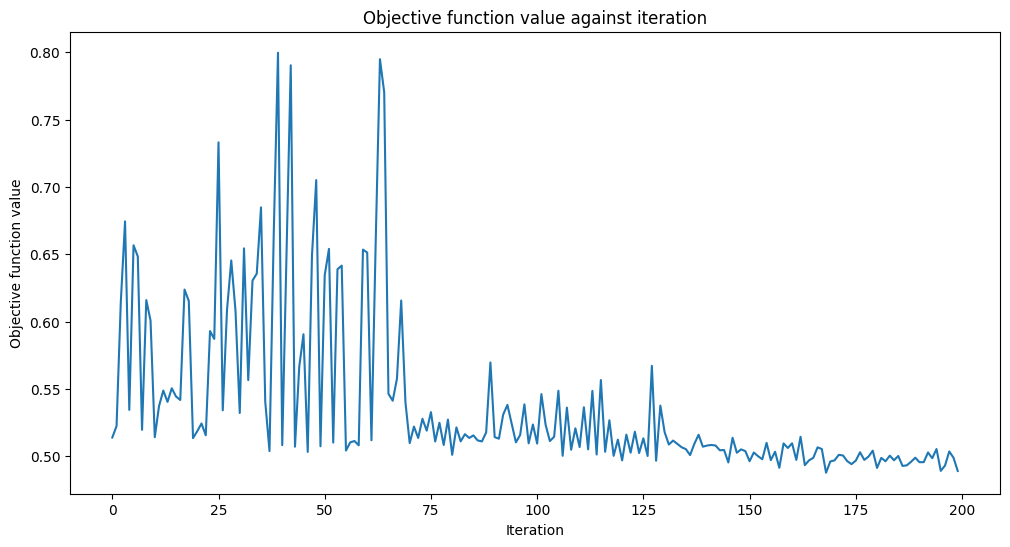

Accuracy from the train data : 94.29%


In [16]:
# QCNN을 훈련한다
x = np.asarray(train_images)
y = np.asarray(train_labels)

objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)
classifier.fit(x, y)

# score classifier
print(f"Accuracy from the train data : {np.round(100 * classifier.score(x, y), 2)}%")

위에서 볼 수 있듯이, QCNN은 천천히 수렴한다. 따라서 우리의 `initial_point`는 이미 최적 해에 가까웠다. 다음 단계는 우리의 QCNN이 테스트 이미지 데이터셋에서 본 데이터를 분류할 수 있는지를 결정하는 것이다.

## 6. QCNN 테스트

우리의 데이터셋을 구축하고 훈련한 후, 우리는 이제 우리의 QCNN이 우리의 테스트 데이터셋에서 나온 것이 아닌 이미지를 예측할 수 있는지를 테스트한다.

Accuracy from the test data : 93.33%


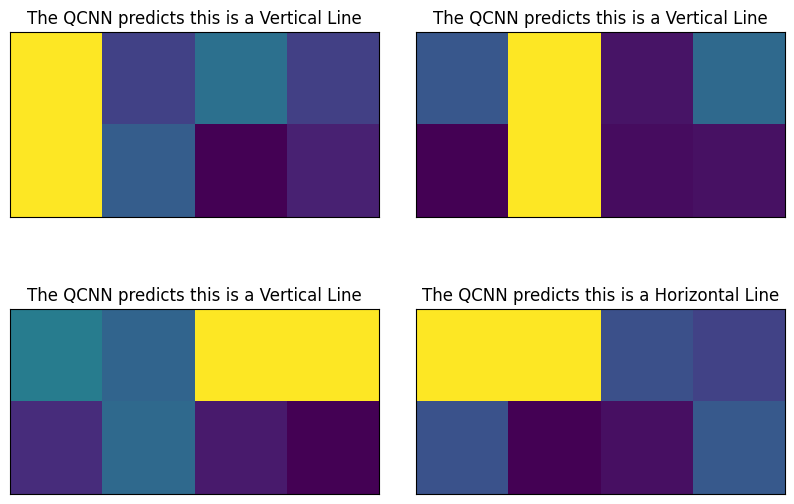

In [17]:
# QCNN의 예측 성능을 테스트한다
y_predict = classifier.predict(test_images)
x = np.asarray(test_images)
y = np.asarray(test_labels)
print(f"Accuracy from the test data : {np.round(100 * classifier.score(x, y), 2)}%")

# Let's see some examples in our dataset
fig, ax = plt.subplots(2, 2, figsize=(10, 6), subplot_kw={"xticks": [], "yticks": []})
for i in range(0, 4):
    ax[i // 2, i % 2].imshow(test_images[i].reshape(2, 4), aspect="equal")
    if y_predict[i] == -1:
        ax[i // 2, i % 2].set_title("The QCNN predicts this is a Horizontal Line")
    if y_predict[i] == +1:
        ax[i // 2, i % 2].set_title("The QCNN predicts this is a Vertical Line")
plt.subplots_adjust(wspace=0.1, hspace=0.5)

위에서 볼 수 있듯이, 우리의 QCNN은 실제로 수평 및 수직 선을 분류할 수 있다! 축하한다! 양자 회로와 양자 합성곱 및 풀링 층을 사용함으로써, 우리는 양자 합성곱 신경망을 구축했다!

In [1]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright